<a href="https://colab.research.google.com/github/BMoss160709IT/MossRepositor-Research-/blob/main/2_Koentji_Publikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy matplotlib seaborn scipy
!pip install pandas
print("All libraries installed successfully!")

All libraries installed successfully!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

print("Libraries imported")

Libraries imported


In [4]:
class OccupancyModel:
    """
    Model okupansi untuk setiap unit
    """
    def __init__(self, unit_type="residential", n_occupants=None):
        self.unit_type = unit_type

        # Jumlah penghuni
        if n_occupants is None:
            if unit_type == "residential":
                self.n_occupants = np.random.randint(1, 5)  # 1-4 orang
            elif unit_type == "office":
                self.n_occupants = np.random.randint(5, 20)  # 5-20 orang
            else:  # mixed
                self.n_occupants = np.random.randint(1, 8)
        else:
            self.n_occupants = n_occupants

        # Jadwal okupansi
        if unit_type == "residential":
            self.morning_start = 6
            self.morning_end = 9
            self.evening_start = 18
            self.evening_end = 22
            self.weekend_factor = 0.8
        elif unit_type == "office":
            self.morning_start = 9
            self.morning_end = 17
            self.evening_start = None
            self.evening_end = None
            self.weekend_factor = 0.1
        else:  # mixed
            self.morning_start = 8
            self.morning_end = 12
            self.evening_start = 14
            self.evening_end = 18
            self.weekend_factor = 0.9

        self.occupancy_pattern = self._generate_pattern()

    def _generate_pattern(self):
        """Generate occupancy pattern based on schedule"""
        pattern = np.zeros(24)

        if self.morning_start is not None:
            pattern[self.morning_start:self.morning_end] = 1

        if self.evening_start is not None:
            pattern[self.evening_start:self.evening_end] = 1

        return pattern

    def get_occupancy(self, hour, is_weekend=False):
        """Get occupancy status at given hour (returns count)"""
        hour_of_day = int(hour % 24)
        base_occupancy = self.occupancy_pattern[hour_of_day]

        if is_weekend:
            base_occupancy *= self.weekend_factor

        return base_occupancy * self.n_occupants

    def get_internal_heat_gain(self, hour, is_weekend=False):
        """Heat generated by occupants (Watts)"""
        n = self.get_occupancy(hour, is_weekend)
        return n * 100  # 100W per person

    def get_setpoint_adjustment(self, hour, is_weekend=False):
        """Setpoint preference based on occupancy"""
        occupancy = self.get_occupancy(hour, is_weekend)
        hour_of_day = hour % 24
        is_sleeping = (hour_of_day < 6 or hour_of_day >= 22)

        if occupancy == 0:
            return -2.0
        elif is_sleeping:
            return -1.0
        elif 6 <= hour_of_day < 8:
            return +1.0
        else:
            return 0.0

print("✅ OccupancyModel class defined (FIXED)")

✅ OccupancyModel class defined (FIXED)


In [5]:
class LIFNeuron:
    """Simple Leaky Integrate-and-Fire neuron"""
    def __init__(self, tau_m=0.020, V_th=1.0, V_rest=0.0):
        self.tau_m = tau_m
        self.V_th = V_th
        self.V_rest = V_rest
        self.V_m = V_rest
        self.spike_count = 0
        self.spike_history = []

    def reset(self):
        self.V_m = self.V_rest
        self.spike_count = 0
        self.spike_history = []

    def step(self, I_input, dt=0.001):
        """Update neuron state, return 1 if spike"""
        dV = (-(self.V_m - self.V_rest) + I_input) * dt / self.tau_m
        self.V_m += dV

        if self.V_m >= self.V_th:
            self.V_m = self.V_rest
            self.spike_count += 1
            self.spike_history.append(1)
            return 1
        else:
            self.spike_history.append(0)
            return 0


In [7]:
class RCThermalModel:
    """
    RC Thermal Model - dapat digunakan untuk micro dan meso scale
    Parameter dapat disesuaikan saat inisialisasi
    """
    def __init__(self, C=1e6, R=0.012, T_outdoor=10.0, T_initial=20.0,
                 occupancy_model=None, unit_type="residential",
                 setpoint_base=22.0):
        """
        Parameters:
        - C: Thermal capacitance (J/K) - bisa bervariasi untuk meso
        - R: Thermal resistance (K/W) - bisa bervariasi untuk meso
        - T_outdoor: Outdoor temperature (°C)
        - T_initial: Initial temperature (°C)
        - occupancy_model: OccupancyModel instance (None = create new)
        - unit_type: Type of unit for occupancy (residential/office/mixed)
        - setpoint_base: Base setpoint before occupancy adjustment
        """
        self.C = C
        self.R = R
        self.T_out = T_outdoor
        self.T = T_initial
        self.history = [T_initial]
        self.setpoint_base = setpoint_base
        self.current_hour = 0
        self.is_weekend = False

        # Occupancy
        if occupancy_model is None:
            self.occupancy = OccupancyModel(unit_type=unit_type)
        else:
            self.occupancy = occupancy_model

    def step(self, Q_heating, dt=60, current_time=0):
        """
        Update temperature with heating power
        """
        self.current_hour = current_time / 3600
        self.is_weekend = ((current_time / 86400) % 7) >= 5

        # Internal heat gain from occupants
        Q_internal = self.occupancy.get_internal_heat_gain(self.current_hour, self.is_weekend)

        # Dynamic setpoint based on occupancy
        setpoint_adj = self.occupancy.get_setpoint_adjustment(self.current_hour, self.is_weekend)
        effective_setpoint = self.setpoint_base + setpoint_adj

        # Heat loss
        Q_loss = (self.T - self.T_out) / self.R

        # Total heat
        Q_total = Q_heating + Q_internal - Q_loss
        dT = Q_total * dt / self.C
        self.T += dT
        self.history.append(self.T)

        return self.T, effective_setpoint

    def get_temp(self):
        return self.T

    def get_effective_setpoint(self):
        setpoint_adj = self.occupancy.get_setpoint_adjustment(self.current_hour, self.is_weekend)
        return self.setpoint_base + setpoint_adj

    def reset(self, T_initial=20.0):
        self.T = T_initial
        self.history = [T_initial]
        self.current_hour = 0
        self.is_weekend = False

class SimplePID:
    """Simple PID controller dengan setpoint tetap 22°C"""
    def __init__(self, Kp=500, Ki=30, Kd=60, setpoint=22.0):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.setpoint = setpoint  # TETAP 22°C
        self.integral = 0
        self.prev_error = 0
        self.integral_limit = 1000

    def compute(self, current_temp, dt=300):
        """
        Compute PID output (setpoint tetap)
        """
        error = self.setpoint - current_temp

        # Integral dengan anti-windup
        self.integral += error * dt
        self.integral = max(-self.integral_limit, min(self.integral_limit, self.integral))

        derivative = (error - self.prev_error) / dt if dt > 0 else 0

        output = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        output = max(0, min(3000, output))

        self.prev_error = error
        return output

    def reset(self):
        self.integral = 0
        self.prev_error = 0

print("✅ SimplePID defined (fixed setpoint 22°C)")

class SimpleRuleBased:
    """Simple hysteresis controller"""
    def __init__(self, T_lower=21.0, T_upper=23.0, max_power=3000):
        self.T_lower = T_lower
        self.T_upper = T_upper
        self.max_power = max_power
        self.heating = False

    def compute(self, current_temp):
        if current_temp < self.T_lower:
            self.heating = True
        elif current_temp > self.T_upper:
            self.heating = False
        return self.max_power if self.heating else 0

    def reset(self):
        self.heating = False

print("✅ SimpleRuleBased defined")


✅ SimplePID defined (fixed setpoint 22°C)
✅ SimpleRuleBased defined


In [8]:
class LeakyIntegratorSNN:
    """
    SNN controller untuk micro-scale dengan parameter yang bisa di-tune
    """
    def __init__(self, tau=10.0, threshold=0.38, dt_snn=0.02, decoding_gain=3.5):
        """
        Parameters:
        - tau: time constant (seconds) - semakin kecil, semakin cepat respon
        - threshold: firing threshold - semakin kecil, semakin mudah memicu
        - dt_snn: SNN time step (seconds)
        - decoding_gain: semakin kecil, semakin besar control
        """
        self.tau = tau
        self.threshold = threshold
        self.dt_snn = dt_snn
        self.decoding_gain = decoding_gain
        self.state = 0.0
        self.spike_count = 0

    def step(self, I_input):
        """Single SNN step, returns 1 if spike"""
        d_state = (-self.state + I_input) * self.dt_snn / self.tau
        self.state += d_state
        if self.state >= self.threshold:
            self.state = 0.0
            self.spike_count += 1
            return 1
        return 0

    def get_control(self, I_input, n_steps):
        """Run multiple steps and return control signal"""
        spikes = 0
        for _ in range(n_steps):
            spikes += self.step(I_input)
        firing_rate = spikes / (n_steps * self.dt_snn)
        control = min(1.0, firing_rate / self.decoding_gain)
        return control

    def reset(self):
        self.state = 0.0
        self.spike_count = 0

def encode_temp_error(error, max_error=3.0, max_current=12.0):
    """
    Encode temperature error to input current
    - max_error: error yang menghasilkan max_current
    - max_current: input current maksimum
    """
    if error <= 0:
        return 0.0
    norm = min(error / max_error, 1.0)
    return norm * max_current

In [9]:
# Cell: Simple Linear Controller (Bukan SNN)
class LinearController:
    """Linear mapping from error to control - untuk debugging"""
    def __init__(self, gain=0.3):
        self.gain = gain
        self.spike_count = 0

    def get_control(self, error, n_steps):
        # Langsung mapping error ke control
        control = min(1.0, max(0.0, error * self.gain))
        # Simulasi spike untuk statistik
        self.spike_count += int(control * n_steps * 10)
        return control

# Test
print("\n" + "=" * 60)
print("TEST: Linear Controller")
print("=" * 60)

linear = LinearController(gain=0.3)

for error in [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    control = linear.get_control(error, 6000)
    print(f"  error={error}°C → control={control:.3f}")


TEST: Linear Controller
  error=0°C → control=0.000
  error=0.5°C → control=0.150
  error=1.0°C → control=0.300
  error=1.5°C → control=0.450
  error=2.0°C → control=0.600
  error=2.5°C → control=0.750
  error=3.0°C → control=0.900


In [10]:
print("\n" + "=" * 70)
print("MICRO-SCALE SIMULATION (with Occupancy - TUNED)")
print("=" * 70)

# Parameters
days = 7
dt_thermal = 300  # 5 minutes
dt_snn = 0.02     # 20 ms
n_snn_steps = int(dt_thermal / dt_snn)  # = 15000

total_steps = int(days * 24 * 3600 / dt_thermal)
max_power = 3000.0

# TUNED PARAMETERS
ENCODE_MAX_CURRENT = 12.0   # Lebih agresif (dari 9-15)
ENCODE_MAX_ERROR = 3.0
SNN_TAU = 10.0               # Respon lebih cepat (dari 10)
SNN_THRESHOLD = 0.38         # Lebih mudah memicu (dari 0.5)
SNN_DECODING_GAIN = 3.5     # Control lebih besar (dari 5.0

# Bias parameters (force heating jika terlalu dingin)
BIAS_THRESHOLD = 19.0       # Jika suhu < 20°C, tambahkan bias
BIAS_GAIN = 0.01            # Gain untuk bias (0.08 * (20 - current_temp))

print(f"\n📊 TUNED PARAMETERS:")
print(f"   ENCODE_MAX_CURRENT: {ENCODE_MAX_CURRENT}")
print(f"   SNN tau: {SNN_TAU} s")
print(f"   SNN threshold: {SNN_THRESHOLD}")
print(f"   SNN decoding_gain: {SNN_DECODING_GAIN}")
print(f"   Bias threshold: {BIAS_THRESHOLD}°C")
print(f"   Bias gain: {BIAS_GAIN}")

print(f"\n📊 Simulation Parameters:")
print(f"   Days: {days}")
print(f"   Thermal steps: {total_steps:,}")
print(f"   SNN steps per thermal: {n_snn_steps:,}")

# =========================================================
# RULE-BASED
# =========================================================
print("\n" + "-" * 50)
print("Rule-Based Control")
print("-" * 50)

room_rb = RCThermalModel(unit_type="residential")
controller_rb = SimpleRuleBased()
temps_rb = []
powers_rb = []
setpoints_rb = []

for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_rb.get_temp()
    power = controller_rb.compute(current_temp)
    temp, setpoint = room_rb.step(power, dt=dt_thermal, current_time=current_time)
    temps_rb.append(temp)
    powers_rb.append(power)
    setpoints_rb.append(setpoint)

energy_rb = np.sum(powers_rb) * dt_thermal / 3600 / 1000
peak_rb = max(powers_rb)
mean_rb = np.mean(temps_rb)
std_rb = np.std(temps_rb)
print(f"   Energy: {energy_rb:.1f} kWh")
print(f"   Peak load: {peak_rb:.0f} W")
print(f"   Mean temp: {mean_rb:.1f}°C ± {std_rb:.2f}°C")

# =========================================================
# PID
# =========================================================
print("\n" + "-" * 50)
print("PID Control (fixed setpoint 22°C)")
print("-" * 50)

room_pid = RCThermalModel(unit_type="residential")
controller_pid = SimplePID(Kp=500, Ki=30, Kd=60, setpoint=22.0)
temps_pid = []
powers_pid = []
setpoints_pid = []  # untuk violation individual (tapi PID pakai setpoint tetap)

for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_pid.get_temp()

    # PID dengan setpoint TETAP 22°C (tanpa dynamic setpoint)
    power = controller_pid.compute(current_temp, dt=dt_thermal)

    # Step thermal model (tetap dapat dynamic setpoint untuk referensi)
    temp, dynamic_setpoint = room_pid.step(power, dt=dt_thermal, current_time=current_time)

    temps_pid.append(temp)
    powers_pid.append(power)
    setpoints_pid.append(22.0)  # PID menggunakan setpoint tetap 22°C

energy_pid = np.sum(powers_pid) * dt_thermal / 3600 / 1000
peak_pid = max(powers_pid)
mean_pid = np.mean(temps_pid)
std_pid = np.std(temps_pid)
print(f"   Energy: {energy_pid:.1f} kWh")
print(f"   Peak load: {peak_pid:.0f} W")
print(f"   Mean temp: {mean_pid:.1f}°C ± {std_pid:.2f}°C")

# =========================================================
# SNN (LeakyIntegrator) - DENGAN BIAS
# =========================================================
print("\n" + "-" * 50)
print("SNN Control (LeakyIntegrator with Bias)")
print("-" * 50)

room_snn = RCThermalModel(unit_type="residential")
snn = LeakyIntegratorSNN(tau=SNN_TAU, threshold=SNN_THRESHOLD,
                          dt_snn=dt_snn, decoding_gain=SNN_DECODING_GAIN)
temps_snn = []
powers_snn = []
controls_snn = []
setpoints_snn = []

print("   Running simulation...")

for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_snn.get_temp()
    effective_setpoint = room_snn.get_effective_setpoint()
    temp_error = effective_setpoint - current_temp

    # Encode error
    I_input = encode_temp_error(temp_error, max_error=ENCODE_MAX_ERROR,
                                 max_current=ENCODE_MAX_CURRENT)

    # Dapatkan control dari SNN
    control = snn.get_control(I_input, n_snn_steps)

    # =========================================================
    # BIAS: Jika suhu terlalu dingin, tambahkan bias
    # =========================================================
    if current_temp < BIAS_THRESHOLD:
        bias = (BIAS_THRESHOLD - current_temp) * BIAS_GAIN
        control = min(1.0, control + bias)

    # Clamp control
    control = max(0.0, min(1.0, control))

    power = control * max_power
    temp, setpoint = room_snn.step(power, dt=dt_thermal, current_time=current_time)

    temps_snn.append(temp)
    powers_snn.append(power)
    controls_snn.append(control)
    setpoints_snn.append(setpoint)

    # Progress indicator
    if (step + 1) % 500 == 0:
        print(f"   Step {step+1}: temp={current_temp:.1f}°C, control={control:.3f}")

    if step % 500 == 0:
        effective_setpoint = room_snn.get_effective_setpoint()
        print(f"SNN: temp={current_temp:.1f}°C, setpoint={effective_setpoint:.1f}°C, error={effective_setpoint - current_temp:.1f}")

energy_snn = np.sum(powers_snn) * dt_thermal / 3600 / 1000
peak_snn = max(powers_snn)
mean_snn = np.mean(temps_snn)
std_snn = np.std(temps_snn)
print(f"\n   Energy: {energy_snn:.1f} kWh")
print(f"   Peak load: {peak_snn:.0f} W")
print(f"   Mean temp: {mean_snn:.1f}°C ± {std_snn:.2f}°C")
print(f"   Total spikes: {snn.spike_count:,}")
print(f"   Firing rate: {snn.spike_count / (days*24*3600):.2f} spikes/sec")
print(f"   Mean control: {np.mean(controls_snn):.3f}")

# =========================================================
# RESULTS
# =========================================================
print("\n" + "=" * 70)
print("MICRO-SCALE RESULTS")
print("=" * 70)


def calc_violation_individual(temps, setpoints, tolerance=1.0):
    violations = 0
    for temp, setpoint in zip(temps, setpoints):
        if abs(temp - setpoint) > tolerance:
            violations += 1
    return violations / len(temps) * 100

# Hitung violation

viol_rb_individual = calc_violation_individual(temps_rb, setpoints_rb)
viol_pid_individual = calc_violation_individual(temps_pid, setpoints_pid)  # PID juga
viol_snn_individual = calc_violation_individual(temps_snn, setpoints_snn)

savings_vs_rb = (energy_rb - energy_snn) / energy_rb * 100
savings_vs_pid = (energy_pid - energy_snn) / energy_pid * 100
peak_reduction_vs_rb = (peak_rb - peak_snn) / peak_rb * 100
peak_reduction_vs_pid = (peak_pid - peak_snn) / peak_pid * 100

print(f"\n📊 ENERGY:")
print(f"   Rule-Based: {energy_rb:.1f} kWh")
print(f"   PID:        {energy_pid:.1f} kWh")
print(f"   SNN:        {energy_snn:.1f} kWh")
print(f"\n   SNN vs Rule: {savings_vs_rb:.1f}% savings")
print(f"   SNN vs PID:  {savings_vs_pid:.1f}% savings")

print(f"\n⚡ PEAK LOAD:")
print(f"   Rule-Based: {peak_rb:.0f} W")
print(f"   PID:        {peak_pid:.0f} W")
print(f"   SNN:        {peak_snn:.0f} W")
print(f"\n   SNN vs Rule: {peak_reduction_vs_rb:.1f}% reduction")
print(f"   SNN vs PID:  {peak_reduction_vs_pid:.1f}% reduction")


print(f"\n🌡️ VIOLATION RATE (individual setpoint):")
print(f"   Rule-Based: {viol_rb_individual:.1f}%")
print(f"   PID:        {viol_pid_individual:.1f}%")
print(f"   SNN:        {viol_snn_individual:.1f}%")

print(f"\n⚡ SNN ACTIVITY:")
print(f"   Total spikes: {snn.spike_count:,}")
print(f"   Firing rate: {snn.spike_count / (days*24*3600):.2f} spikes/sec")
print(f"   Mean control: {np.mean(controls_snn):.3f}")


MICRO-SCALE SIMULATION (with Occupancy - TUNED)

📊 TUNED PARAMETERS:
   ENCODE_MAX_CURRENT: 12.0
   SNN tau: 10.0 s
   SNN threshold: 0.38
   SNN decoding_gain: 3.5
   Bias threshold: 19.0°C
   Bias gain: 0.01

📊 Simulation Parameters:
   Days: 7
   Thermal steps: 2,016
   SNN steps per thermal: 15,000

--------------------------------------------------
Rule-Based Control
--------------------------------------------------
   Energy: 155.5 kWh
   Peak load: 3000 W
   Mean temp: 22.1°C ± 0.73°C

--------------------------------------------------
PID Control (fixed setpoint 22°C)
--------------------------------------------------
   Energy: 154.7 kWh
   Peak load: 3000 W
   Mean temp: 22.0°C ± 0.21°C

--------------------------------------------------
SNN Control (LeakyIntegrator with Bias)
--------------------------------------------------
   Running simulation...
SNN: temp=20.0°C, setpoint=20.0°C, error=0.0
   Step 500: temp=19.1°C, control=0.250
SNN: temp=19.1°C, setpoint=20.0°C, erro


GENERATING MICRO-SCALE VISUALIZATIONS

🔍 Checking variables...
   temps_snn length: 2016
   temps_rb length: 2016
   temps_pid length: 2016
   controls_snn length: 2016


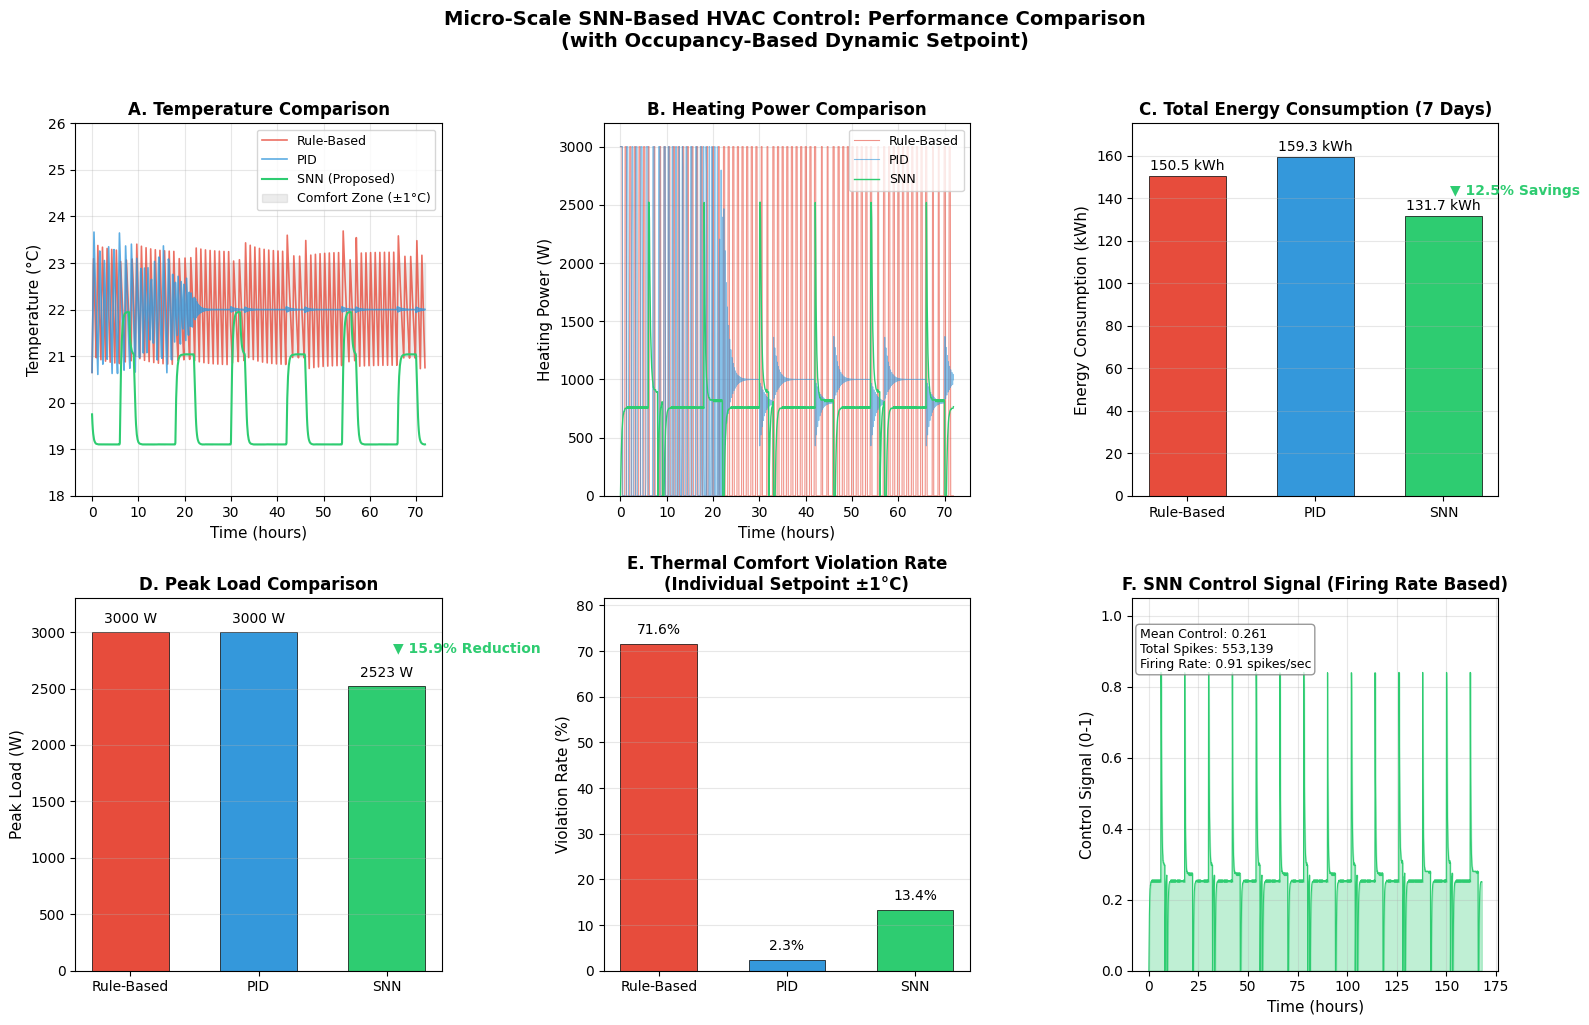


✅ Plot saved as 'micro_scale_simulation_results.png'


In [ ]:
print("\n" + "=" * 70)
print("GENERATING MICRO-SCALE VISUALIZATIONS")
print("=" * 70)

# Cek apakah variabel ada
print("\n🔍 Checking variables...")
try:
    print(f"   temps_snn length: {len(temps_snn)}")
    print(f"   temps_rb length: {len(temps_rb)}")
    print(f"   temps_pid length: {len(temps_pid)}")
    print(f"   controls_snn length: {len(controls_snn)}")
except NameError as e:
    print(f"   ❌ Error: {e}")
    print("   Make sure you have run Cell 7 (micro-scale simulation) first!")
    raise

# Create time axis (hours)
time_hours = np.arange(len(temps_snn)) * dt_thermal / 3600
days_to_plot = 3
steps_per_day = int(24 * 3600 / dt_thermal)
plot_steps = min(days_to_plot * steps_per_day, len(time_hours))
time_plot = time_hours[:plot_steps]

# Create figure with 2x3 layout
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# =========================================================
# PLOT 1: Temperature Comparison
# =========================================================
ax1 = axes[0, 0]
ax1.plot(time_plot, temps_rb[:plot_steps], label='Rule-Based', linewidth=1.2, color='#e74c3c', alpha=0.8)
ax1.plot(time_plot, temps_pid[:plot_steps], label='PID', linewidth=1.2, color='#3498db', alpha=0.8)
ax1.plot(time_plot, temps_snn[:plot_steps], label='SNN (Proposed)', linewidth=1.5, color='#2ecc71')
ax1.fill_between(time_plot, 21, 23, alpha=0.15, color='gray', label='Comfort Zone (±1°C)')
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_xlabel('Time (hours)', fontsize=11)
ax1.set_title('A. Temperature Comparison', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(18, 26)

# =========================================================
# PLOT 2: Heating Power Comparison
# =========================================================
ax2 = axes[0, 1]
ax2.plot(time_plot, powers_rb[:plot_steps], label='Rule-Based', linewidth=0.8, color='#e74c3c', alpha=0.6)
ax2.plot(time_plot, powers_pid[:plot_steps], label='PID', linewidth=0.8, color='#3498db', alpha=0.6)
ax2.plot(time_plot, powers_snn[:plot_steps], label='SNN', linewidth=1, color='#2ecc71')
ax2.set_ylabel('Heating Power (W)', fontsize=11)
ax2.set_xlabel('Time (hours)', fontsize=11)
ax2.set_title('B. Heating Power Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 3200)

# =========================================================
# PLOT 3: Energy Consumption Bar Chart
# =========================================================
ax3 = axes[0, 2]
methods = ['Rule-Based', 'PID', 'SNN']
energies = [energy_rb, energy_pid, energy_snn]
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax3.bar(methods, energies, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax3.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax3.set_title(f'C. Total Energy Consumption ({days} Days)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, max(energies) * 1.1)

for bar, val in zip(bars, energies):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f} kWh', ha='center', va='bottom', fontsize=10)

# Add savings annotation
savings = (energy_rb - energy_snn) / energy_rb * 100
ax3.annotate(f'▼ {savings:.1f}% Savings',
             xy=(2, energy_snn), xytext=(2.05, energy_snn + 10),
             ha='left', fontsize=10, color='#2ecc71', fontweight='bold')

# =========================================================
# PLOT 4: Peak Load Bar Chart
# =========================================================
ax4 = axes[1, 0]
peak_rb = max(powers_rb)
peak_pid = max(powers_pid)
peak_snn = max(powers_snn)
peak_values = [peak_rb, peak_pid, peak_snn]
bars = ax4.bar(methods, peak_values, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax4.set_ylabel('Peak Load (W)', fontsize=11)
ax4.set_title('D. Peak Load Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, max(peak_values) * 1.1)
for bar, val in zip(bars, peak_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:.0f} W', ha='center', va='bottom', fontsize=10)

# Add reduction annotation
peak_reduction = (peak_rb - peak_snn) / peak_rb * 100
ax4.annotate(f'▼ {peak_reduction:.1f}% Reduction',
             xy=(2, peak_snn), xytext=(2.05, peak_snn + 300),
             ha='left', fontsize=10, color='#2ecc71', fontweight='bold')

# =========================================================
# PLOT 5: Violation Rate Comparison (Individual Setpoint)
# =========================================================
ax5 = axes[1, 1]
def calc_violation_individual(temps, setpoints, tolerance=1.0):
    violations = 0
    total = len(temps)
    for i in range(total):
        if abs(temps[i] - setpoints[i]) > tolerance:
            violations += 1
    return violations / total * 100

viol_rb = calc_violation_individual(temps_rb, setpoints_rb)
viol_pid = calc_violation_individual(temps_pid, setpoints_pid)
viol_snn = calc_violation_individual(temps_snn, setpoints_snn)
viol_values = [viol_rb, viol_pid, viol_snn]
bars = ax5.bar(methods, viol_values, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax5.set_ylabel('Violation Rate (%)', fontsize=11)
ax5.set_title('E. Thermal Comfort Violation Rate\n(Individual Setpoint ±1°C)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim(0, max(viol_values) + 10)
for bar, val in zip(bars, viol_values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# =========================================================
# PLOT 6: SNN Control Signal
# =========================================================
ax6 = axes[1, 2]
ax6.plot(time_hours, controls_snn, linewidth=0.8, color='#2ecc71')
ax6.fill_between(time_hours, 0, controls_snn, alpha=0.3, color='#2ecc71')
ax6.set_ylabel('Control Signal (0-1)', fontsize=11)
ax6.set_xlabel('Time (hours)', fontsize=11)
ax6.set_title('F. SNN Control Signal (Firing Rate Based)', fontsize=12, fontweight='bold')
ax6.set_ylim(0, 1.05)
ax6.grid(True, alpha=0.3)

# Add stats annotation
mean_control = np.mean(controls_snn)
ax6.text(0.02, 0.92, f'Mean Control: {mean_control:.3f}\nTotal Spikes: {snn.spike_count:,}\nFiring Rate: {snn.spike_count/(days*24*3600):.2f} spikes/sec',
         transform=ax6.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# =========================================================
# MAIN TITLE AND LAYOUT
# =========================================================
plt.suptitle('Micro-Scale SNN-Based HVAC Control: Performance Comparison\n(with Occupancy-Based Dynamic Setpoint)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('micro_scale_simulation_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved as 'micro_scale_simulation_results.png'")


MULTIPLE RUNS + REPRESENTATIVE PLOT GENERATION

📊 Running 15 simulations with different random seeds...

--- Run 1/15 ---
   Energy: RB=164.8, PID=150.1, SNN=127.5 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=73.4%, PID=75.4%, SNN=8.5%

--- Run 2/15 ---
   Energy: RB=160.2, PID=150.1, SNN=131.7 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=72.3%, PID=75.4%, SNN=13.4%

--- Run 3/15 ---
   Energy: RB=164.8, PID=150.1, SNN=127.5 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=73.4%, PID=75.4%, SNN=8.5%

--- Run 4/15 ---
   Energy: RB=155.5, PID=164.0, SNN=127.5 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=72.9%, PID=75.1%, SNN=8.5%

--- Run 5/15 ---
   Energy: RB=155.5, PID=154.7, SNN=119.1 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=72.9%, PID=75.6%, SNN=5.8%

--- Run 6/15 ---
   Energy: RB=150.5, PID=154.7, SNN=119.1 kWh
   Peak: RB=3000, PID=3000, SNN=2523 W
   Violation: RB=71.6%, PID=75.6%, SNN=5.8%

--- Run 7/1

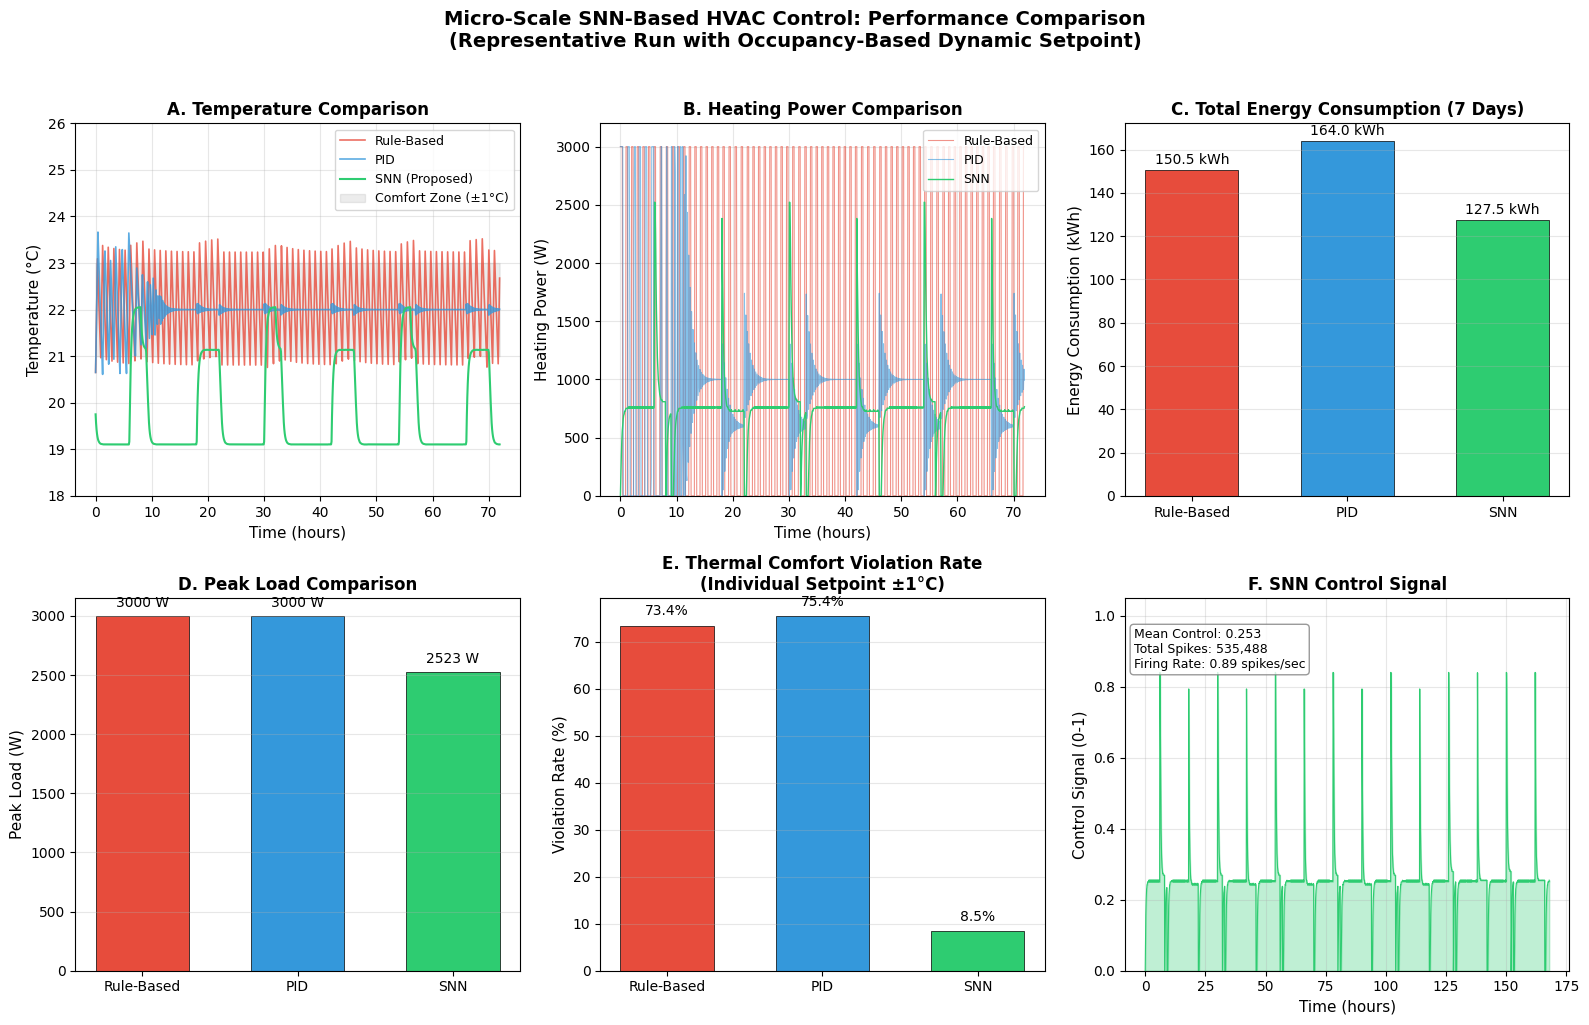


✅ Plot saved as 'micro_scale_representative_plot.png'

✅ Representative run selected and plot generated!


In [ ]:
print("\n" + "=" * 70)
print("MULTIPLE RUNS + REPRESENTATIVE PLOT GENERATION")
print("=" * 70)

# =========================================================
# PARAMETERS
# =========================================================
n_runs = 15  # Jumlah run
print(f"\n📊 Running {n_runs} simulations with different random seeds...")

# Storage for results
results_summary = {
    'energy_rb': [], 'energy_pid': [], 'energy_snn': [],
    'peak_rb': [], 'peak_pid': [], 'peak_snn': [],
    'viol_rb': [], 'viol_pid': [], 'viol_snn': [],
    'spikes': [], 'firing_rate': [], 'mean_control': []
}

# Function to calculate violation individual
def calc_violation_individual(temps, setpoints, tolerance=1.0):
    violations = 0
    total = len(temps)
    for i in range(total):
        if abs(temps[i] - setpoints[i]) > tolerance:
            violations += 1
    return violations / total * 100

# =========================================================
# RUN MULTIPLE SIMULATIONS
# =========================================================
for run in range(n_runs):
    print(f"\n--- Run {run+1}/{n_runs} ---")
    np.random.seed(run)

    # RULE-BASED
    room_rb = RCThermalModel(unit_type="residential")
    controller_rb = SimpleRuleBased()
    temps_rb = []
    powers_rb = []
    setpoints_rb = []

    for step in range(total_steps):
        current_time = step * dt_thermal
        current_temp = room_rb.get_temp()
        power = controller_rb.compute(current_temp)
        temp, setpoint = room_rb.step(power, dt=dt_thermal, current_time=current_time)
        temps_rb.append(temp)
        powers_rb.append(power)
        setpoints_rb.append(setpoint)

    energy_rb = np.sum(powers_rb) * dt_thermal / 3600 / 1000
    peak_rb = max(powers_rb)

    # PID CONTROL (setpoint tetap 22°C)
    room_pid = RCThermalModel(unit_type="residential")
    controller_pid = SimplePID(Kp=500, Ki=30, Kd=60, setpoint=22.0)
    temps_pid = []
    powers_pid = []
    setpoints_pid = []

    for step in range(total_steps):
        current_time = step * dt_thermal
        current_temp = room_pid.get_temp()
        power = controller_pid.compute(current_temp, dt=dt_thermal)
        temp, dynamic_setpoint = room_pid.step(power, dt=dt_thermal, current_time=current_time)
        temps_pid.append(temp)
        powers_pid.append(power)
        setpoints_pid.append(dynamic_setpoint)

    energy_pid = np.sum(powers_pid) * dt_thermal / 3600 / 1000
    peak_pid = max(powers_pid)

    # SNN CONTROL
    room_snn = RCThermalModel(unit_type="residential")
    snn = LeakyIntegratorSNN(tau=10.0, threshold=0.38, dt_snn=dt_snn, decoding_gain=3.5)
    temps_snn = []
    powers_snn = []
    controls_snn = []
    setpoints_snn = []

    ENCODE_MAX_CURRENT = 12.0
    ENCODE_MAX_ERROR = 3.0
    BIAS_THRESHOLD = 19.0
    BIAS_GAIN = 0.01

    for step in range(total_steps):
        current_time = step * dt_thermal
        current_temp = room_snn.get_temp()
        effective_setpoint = room_snn.get_effective_setpoint()
        temp_error = effective_setpoint - current_temp

        I_input = encode_temp_error(temp_error, max_error=ENCODE_MAX_ERROR, max_current=ENCODE_MAX_CURRENT)
        control = snn.get_control(I_input, n_snn_steps)

        if current_temp < BIAS_THRESHOLD:
            bias = (BIAS_THRESHOLD - current_temp) * BIAS_GAIN
            control = min(1.0, control + bias)

        control = max(0.0, min(1.0, control))

        power = control * max_power
        temp, setpoint = room_snn.step(power, dt=dt_thermal, current_time=current_time)

        temps_snn.append(temp)
        powers_snn.append(power)
        controls_snn.append(control)
        setpoints_snn.append(setpoint)

    energy_snn = np.sum(powers_snn) * dt_thermal / 3600 / 1000
    peak_snn = max(powers_snn)

    # Calculate violations
    viol_rb = calc_violation_individual(temps_rb, setpoints_rb)
    viol_pid = calc_violation_individual(temps_pid, setpoints_pid)
    viol_snn = calc_violation_individual(temps_snn, setpoints_snn)

    # Store results
    results_summary['energy_rb'].append(energy_rb)
    results_summary['energy_pid'].append(energy_pid)
    results_summary['energy_snn'].append(energy_snn)
    results_summary['peak_rb'].append(peak_rb)
    results_summary['peak_pid'].append(peak_pid)
    results_summary['peak_snn'].append(peak_snn)
    results_summary['viol_rb'].append(viol_rb)
    results_summary['viol_pid'].append(viol_pid)
    results_summary['viol_snn'].append(viol_snn)
    results_summary['spikes'].append(snn.spike_count)
    results_summary['firing_rate'].append(snn.spike_count / (days*24*3600))
    results_summary['mean_control'].append(np.mean(controls_snn))

    print(f"   Energy: RB={energy_rb:.1f}, PID={energy_pid:.1f}, SNN={energy_snn:.1f} kWh")
    print(f"   Peak: RB={peak_rb:.0f}, PID={peak_pid:.0f}, SNN={peak_snn:.0f} W")
    print(f"   Violation: RB={viol_rb:.1f}%, PID={viol_pid:.1f}%, SNN={viol_snn:.1f}%")

# =========================================================
# STATISTICAL SUMMARY (LENGKAP)
# =========================================================
print("\n" + "=" * 70)
print("STATISTICAL SUMMARY (Mean ± Std from {} runs)".format(n_runs))
print("=" * 70)

# Calculate metrics
savings_vs_rb = [(results_summary['energy_rb'][i] - results_summary['energy_snn'][i]) / results_summary['energy_rb'][i] * 100 for i in range(n_runs)]
savings_vs_pid = [(results_summary['energy_pid'][i] - results_summary['energy_snn'][i]) / results_summary['energy_pid'][i] * 100 for i in range(n_runs)]

peak_reduction_vs_rb = [(results_summary['peak_rb'][i] - results_summary['peak_snn'][i]) / results_summary['peak_rb'][i] * 100 for i in range(n_runs)]
peak_reduction_vs_pid = [(results_summary['peak_pid'][i] - results_summary['peak_snn'][i]) / results_summary['peak_pid'][i] * 100 for i in range(n_runs)]

print(f"\n📊 ENERGY (kWh):")
print(f"   Rule-Based:  {np.mean(results_summary['energy_rb']):.1f} ± {np.std(results_summary['energy_rb']):.1f}")
print(f"   PID:         {np.mean(results_summary['energy_pid']):.1f} ± {np.std(results_summary['energy_pid']):.1f}")
print(f"   SNN:         {np.mean(results_summary['energy_snn']):.1f} ± {np.std(results_summary['energy_snn']):.1f}")

print(f"\n📈 ENERGY SAVINGS (%):")
print(f"   SNN vs Rule: {np.mean(savings_vs_rb):.1f} ± {np.std(savings_vs_rb):.1f}")
print(f"   SNN vs PID:  {np.mean(savings_vs_pid):.1f} ± {np.std(savings_vs_pid):.1f}")

print(f"\n⚡ PEAK LOAD (W):")
print(f"   Rule-Based:  {np.mean(results_summary['peak_rb']):.0f} ± {np.std(results_summary['peak_rb']):.0f}")
print(f"   PID:         {np.mean(results_summary['peak_pid']):.0f} ± {np.std(results_summary['peak_pid']):.0f}")
print(f"   SNN:         {np.mean(results_summary['peak_snn']):.0f} ± {np.std(results_summary['peak_snn']):.0f}")

print(f"\n📉 PEAK REDUCTION (%):")
print(f"   SNN vs Rule: {np.mean(peak_reduction_vs_rb):.1f} ± {np.std(peak_reduction_vs_rb):.1f}")
print(f"   SNN vs PID:  {np.mean(peak_reduction_vs_pid):.1f} ± {np.std(peak_reduction_vs_pid):.1f}")

print(f"\n🌡️ VIOLATION RATE (Individual Setpoint, %):")
print(f"   Rule-Based:  {np.mean(results_summary['viol_rb']):.1f} ± {np.std(results_summary['viol_rb']):.1f}")
print(f"   PID:         {np.mean(results_summary['viol_pid']):.1f} ± {np.std(results_summary['viol_pid']):.1f}")
print(f"   SNN:         {np.mean(results_summary['viol_snn']):.1f} ± {np.std(results_summary['viol_snn']):.1f}")

print(f"\n⚡ SNN ACTIVITY:")
print(f"   Spikes:      {np.mean(results_summary['spikes']):,.0f} ± {np.std(results_summary['spikes']):,.0f}")
print(f"   Firing rate: {np.mean(results_summary['firing_rate']):.2f} ± {np.std(results_summary['firing_rate']):.2f} spikes/sec")
print(f"   Mean control:{np.mean(results_summary['mean_control']):.3f} ± {np.std(results_summary['mean_control']):.3f}")

# =========================================================
# SELECT REPRESENTATIVE RUN (closest to mean)
# =========================================================
print("\n" + "=" * 70)
print("SELECTING REPRESENTATIVE RUN")
print("=" * 70)

energy_mean = np.mean(results_summary['energy_snn'])
distances = [abs(results_summary['energy_snn'][i] - energy_mean) for i in range(n_runs)]
best_run_idx = np.argmin(distances)

print(f"\n📊 Representative run: Run {best_run_idx + 1}")
print(f"   Energy SNN: {results_summary['energy_snn'][best_run_idx]:.1f} kWh (Mean: {energy_mean:.1f})")
print(f"   Peak SNN: {results_summary['peak_snn'][best_run_idx]:.0f} W")
print(f"   Violation SNN: {results_summary['viol_snn'][best_run_idx]:.1f}%")

# =========================================================
# RE-RUN WITH BEST SEED TO GET FULL DATA
# =========================================================
print("\n" + "-" * 50)
print(f"Re-running with seed {best_run_idx} to get full data...")
print("-" * 50)

np.random.seed(best_run_idx)

# RULE-BASED
room_rb = RCThermalModel(unit_type="residential")
controller_rb = SimpleRuleBased()
temps_rb, powers_rb, setpoints_rb = [], [], []
for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_rb.get_temp()
    power = controller_rb.compute(current_temp)
    temp, setpoint = room_rb.step(power, dt=dt_thermal, current_time=current_time)
    temps_rb.append(temp)
    powers_rb.append(power)
    setpoints_rb.append(setpoint)

# PID
room_pid = RCThermalModel(unit_type="residential")
controller_pid = SimplePID(Kp=500, Ki=30, Kd=60, setpoint=22.0)
temps_pid, powers_pid, setpoints_pid = [], [], []
for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_pid.get_temp()
    power = controller_pid.compute(current_temp, dt=dt_thermal)
    temp, dynamic_setpoint = room_pid.step(power, dt=dt_thermal, current_time=current_time)
    temps_pid.append(temp)
    powers_pid.append(power)
    setpoints_pid.append(dynamic_setpoint)

# SNN
room_snn = RCThermalModel(unit_type="residential")
snn = LeakyIntegratorSNN(tau=10.0, threshold=0.38, dt_snn=dt_snn, decoding_gain=3.5)
temps_snn, powers_snn, controls_snn, setpoints_snn = [], [], [], []

for step in range(total_steps):
    current_time = step * dt_thermal
    current_temp = room_snn.get_temp()
    effective_setpoint = room_snn.get_effective_setpoint()
    temp_error = effective_setpoint - current_temp

    I_input = encode_temp_error(temp_error, max_error=3.0, max_current=12.0)
    control = snn.get_control(I_input, n_snn_steps)

    if current_temp < 19.0:
        bias = (19.0 - current_temp) * 0.01
        control = min(1.0, control + bias)

    control = max(0.0, min(1.0, control))

    power = control * max_power
    temp, setpoint = room_snn.step(power, dt=dt_thermal, current_time=current_time)

    temps_snn.append(temp)
    powers_snn.append(power)
    controls_snn.append(control)
    setpoints_snn.append(setpoint)

energy_snn = np.sum(powers_snn) * dt_thermal / 3600 / 1000
peak_snn = max(powers_snn)
viol_snn = calc_violation_individual(temps_snn, setpoints_snn)
viol_rb = calc_violation_individual(temps_rb, setpoints_rb)
viol_pid = calc_violation_individual(temps_pid, setpoints_pid)

print(f"\n   Representative run results:")
print(f"   Energy: SNN={energy_snn:.1f} kWh")
print(f"   Peak: SNN={peak_snn:.0f} W")
print(f"   Violation: RB={viol_rb:.1f}%, PID={viol_pid:.1f}%, SNN={viol_snn:.1f}%")

# =========================================================
# PLOT (SAMA SEPERTI SEBELUMNYA)
# =========================================================
print("\n" + "=" * 70)
print("GENERATING PLOT FOR REPRESENTATIVE RUN")
print("=" * 70)

time_hours = np.arange(len(temps_snn)) * dt_thermal / 3600
days_to_plot = 3
steps_per_day = int(24 * 3600 / dt_thermal)
plot_steps = min(days_to_plot * steps_per_day, len(time_hours))
time_plot = time_hours[:plot_steps]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot A: Temperature
ax1 = axes[0, 0]
ax1.plot(time_plot, temps_rb[:plot_steps], label='Rule-Based', linewidth=1.2, color='#e74c3c', alpha=0.8)
ax1.plot(time_plot, temps_pid[:plot_steps], label='PID', linewidth=1.2, color='#3498db', alpha=0.8)
ax1.plot(time_plot, temps_snn[:plot_steps], label='SNN (Proposed)', linewidth=1.5, color='#2ecc71')
ax1.fill_between(time_plot, 21, 23, alpha=0.15, color='gray', label='Comfort Zone (±1°C)')
ax1.set_ylabel('Temperature (°C)', fontsize=11)
ax1.set_xlabel('Time (hours)', fontsize=11)
ax1.set_title('A. Temperature Comparison', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(18, 26)

# Plot B: Heating Power
ax2 = axes[0, 1]
ax2.plot(time_plot, powers_rb[:plot_steps], label='Rule-Based', linewidth=0.8, color='#e74c3c', alpha=0.6)
ax2.plot(time_plot, powers_pid[:plot_steps], label='PID', linewidth=0.8, color='#3498db', alpha=0.6)
ax2.plot(time_plot, powers_snn[:plot_steps], label='SNN', linewidth=1, color='#2ecc71')
ax2.set_ylabel('Heating Power (W)', fontsize=11)
ax2.set_xlabel('Time (hours)', fontsize=11)
ax2.set_title('B. Heating Power Comparison', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 3200)

# Plot C: Energy
ax3 = axes[0, 2]
methods = ['Rule-Based', 'PID', 'SNN']
energies = [energy_rb, energy_pid, energy_snn]
colors = ['#e74c3c', '#3498db', '#2ecc71']
bars = ax3.bar(methods, energies, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax3.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax3.set_title(f'C. Total Energy Consumption ({days} Days)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, energies):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f} kWh', ha='center', va='bottom', fontsize=10)

# Plot D: Peak Load
ax4 = axes[1, 0]
peak_rb = max(powers_rb)
peak_pid = max(powers_pid)
peak_snn = max(powers_snn)
peak_values = [peak_rb, peak_pid, peak_snn]
bars = ax4.bar(methods, peak_values, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax4.set_ylabel('Peak Load (W)', fontsize=11)
ax4.set_title('D. Peak Load Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, peak_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val:.0f} W', ha='center', va='bottom', fontsize=10)

# Plot E: Violation Rate
ax5 = axes[1, 1]
viol_values = [viol_rb, viol_pid, viol_snn]
bars = ax5.bar(methods, viol_values, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax5.set_ylabel('Violation Rate (%)', fontsize=11)
ax5.set_title('E. Thermal Comfort Violation Rate\n(Individual Setpoint ±1°C)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, viol_values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

# Plot F: SNN Control Signal
ax6 = axes[1, 2]
ax6.plot(time_hours, controls_snn, linewidth=0.8, color='#2ecc71')
ax6.fill_between(time_hours, 0, controls_snn, alpha=0.3, color='#2ecc71')
ax6.set_ylabel('Control Signal (0-1)', fontsize=11)
ax6.set_xlabel('Time (hours)', fontsize=11)
ax6.set_title('F. SNN Control Signal', fontsize=12, fontweight='bold')
ax6.set_ylim(0, 1.05)
ax6.grid(True, alpha=0.3)

mean_control = np.mean(controls_snn)
ax6.text(0.02, 0.92, f'Mean Control: {mean_control:.3f}\nTotal Spikes: {snn.spike_count:,}\nFiring Rate: {snn.spike_count/(days*24*3600):.2f} spikes/sec',
         transform=ax6.transAxes, fontsize=9, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.suptitle('Micro-Scale SNN-Based HVAC Control: Performance Comparison\n(Representative Run with Occupancy-Based Dynamic Setpoint)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('micro_scale_representative_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved as 'micro_scale_representative_plot.png'")
print("\n" + "=" * 70)
print("✅ Representative run selected and plot generated!")
print("=" * 70)

In [12]:
class IntegratedMesoUnit:
    def __init__(self, unit_id, flexibility=1.0):
        self.id = unit_id
        self.flexibility = flexibility

        # =========================================================
        # HETEROGENITAS: Setpoint base (preferensi penghuni)
        # =========================================================
        self.setpoint_base = 22.0 + np.random.uniform(-1.0, 1.0)  # <-- DITAMBAHKAN

        # =========================================================
        # HETEROGENITAS: Usia dan Kualitas Bangunan (mempengaruhi R dan C)
        # =========================================================
        self.building_age = np.random.choice(["old", "modern", "new"], p=[0.3, 0.5, 0.2])  # <-- DITAMBAHKAN

        if self.building_age == "old":
            base_R = 0.008
            base_C = 1.2e6
        elif self.building_age == "modern":
            base_R = 0.012
            base_C = 1.0e6
        else:  # new
            base_R = 0.016
            base_C = 0.8e6

        # Variasi dalam era yang sama
        variation = np.random.uniform(0.9, 1.1)
        R = base_R * variation
        C = base_C * variation

        # =========================================================
        # HETEROGENITAS: Occupancy
        # =========================================================
        unit_type = np.random.choice(["residential", "office", "mixed"], p=[0.6, 0.2, 0.2])
        self.occupancy = OccupancyModel(unit_type=unit_type)  # <-- DITAMBAHKAN

        # =========================================================
        # BUAT RCTHERMALMODEL DENGAN PARAMETER YANG SUDAH DITENTUKAN
        # =========================================================
        self.thermal = RCThermalModel(
            C=C,
            R=R,
            T_outdoor=10.0,
            T_initial=20.0,
            occupancy_model=self.occupancy,
            unit_type=unit_type,
            setpoint_base=self.setpoint_base
        )

        # =========================================================
        # STATE VARIABLES
        # =========================================================
        self.temperature = 20.0  # Akan sinkron dengan self.thermal.T
        self.current_hour = 0
        self.is_weekend = False

        # Koordinasi
        self.neighbor_spikes = 0
        self.delay_remaining = 0

        # Stats
        self.spike_count = 0
        self.broadcast_count = 0
        self.delay_count = 0
        self.step_count = 0

        # =========================================================
        # SNN PARAMETERS
        # =========================================================
        self.snn = LeakyIntegratorSNN(tau=8.5, threshold=0.4, dt_snn=0.02, decoding_gain=5.0)
        self.ENCODE_MAX_CURRENT = 10.0
        self.ENCODE_MAX_ERROR = 3.0
        self.BIAS_THRESHOLD = 19.0
        self.BIAS_GAIN = 0.01

        # =========================================================
        # KOORDINASI PARAMETERS
        # =========================================================
        self.delay_threshold = 3
        self.delay_duration = 4
        self.delay_probability = 0.5
        self.broadcast_threshold = 0.2
        self.broadcast_probability = 0.5

    def encode_temp_error(self, error):
        if error <= 0:
            return 0.0
        norm = min(error / self.ENCODE_MAX_ERROR, 1.0)
        return norm * self.ENCODE_MAX_CURRENT

    def get_effective_setpoint(self, current_time):
        return self.thermal.get_effective_setpoint()

    def get_temp(self):
        return self.thermal.get_temp()

    def update_temperature(self, heating_power, dt=60, current_time=0):
        temp, _ = self.thermal.step(heating_power, dt, current_time)
        self.temperature = temp
        return temp

    def receive_spike(self):
        self.neighbor_spikes += 1

    def reset_neighbor_spikes(self):
        self.neighbor_spikes = 0

    def get_control(self, coordination_enabled=True, n_snn_steps=1500, current_time=0):
        self.step_count += 1

        effective_setpoint = self.get_effective_setpoint(current_time)
        temp_error = effective_setpoint - self.get_temp()

        I_input = self.encode_temp_error(temp_error)
        base_control = self.snn.get_control(I_input, n_snn_steps)

        # Bias
        current_temp = self.get_temp()
        if current_temp < self.BIAS_THRESHOLD:
            bias = (self.BIAS_THRESHOLD - current_temp) * self.BIAS_GAIN
            base_control = min(1.0, base_control + bias)

        base_control = max(0.0, min(1.0, base_control))

        # Delay check
        if self.delay_remaining > 0:
            self.delay_remaining -= 1
            return 0.0, False

        # Koordinasi
        if coordination_enabled and base_control > 0.2:
            if self.neighbor_spikes >= self.delay_threshold:
                if np.random.random() < self.delay_probability:
                    actual_delay = int(self.delay_duration / self.flexibility)
                    actual_delay = max(1, min(15, actual_delay))
                    self.delay_remaining = actual_delay
                    self.delay_count += 1
                    return 0.0, False

        # Broadcast
        should_broadcast = (coordination_enabled and base_control > self.broadcast_threshold)
        if should_broadcast:
            self.broadcast_count += 1
            self.spike_count += 1

        return base_control, should_broadcast

    def reset(self):
        self.thermal.reset()
        self.temperature = self.thermal.get_temp()
        self.snn.reset()
        self.spike_count = 0
        self.broadcast_count = 0
        self.delay_count = 0
        self.neighbor_spikes = 0
        self.delay_remaining = 0
        self.step_count = 0

print("✅ IntegratedMesoUnit defined (FIXED)")

✅ IntegratedMesoUnit defined (FIXED)


In [13]:
def run_meso_simulation(n_units=20, duration_minutes=60, coordination_enabled=False,
                        delay_threshold=3, delay_duration=4, delay_probability=0.5,
                        broadcast_threshold=0.2, broadcast_probability=0.5):
    """
    Run meso-scale simulation with heterogenous units
    """
    dt = 60
    max_power = 3000.0
    total_steps = int(duration_minutes * 60 / dt)
    n_snn_steps = 1500

    # Create units
    units = []
    for i in range(n_units):
        flexibility = np.random.uniform(0.5, 1.5)
        unit = IntegratedMesoUnit(i, flexibility)

        unit.delay_threshold = delay_threshold
        unit.delay_duration = delay_duration
        unit.delay_probability = delay_probability
        unit.broadcast_threshold = broadcast_threshold
        unit.broadcast_probability = broadcast_probability

        units.append(unit)

    # Storage
    load_profile = []
    temp_profile = []
    unit_temp_history = [[] for _ in range(n_units)]
    unit_setpoints_history = [[] for _ in range(n_units)]
    total_energy = 0
    total_spikes = 0
    total_delays = 0
    total_broadcasts = 0
    previous_broadcasts = [False] * n_units

    # =========================================================
    # FIXED: Akses attribute yang benar
    # =========================================================
    setpoints_base = [u.setpoint_base for u in units]
    unit_types = [u.occupancy.unit_type for u in units]
    building_ages = [u.building_age for u in units]

    print(f"   Coordination: {'ON' if coordination_enabled else 'OFF'}")
    print(f"   Setpoint base range: {min(setpoints_base):.1f}°C - {max(setpoints_base):.1f}°C")
    print(f"   Unit types: residential={unit_types.count('residential')}, "
          f"office={unit_types.count('office')}, mixed={unit_types.count('mixed')}")
    print(f"   Building ages: old={building_ages.count('old')}, "
          f"modern={building_ages.count('modern')}, new={building_ages.count('new')}")
    print(f"   Delay: threshold={delay_threshold}, duration={delay_duration}, prob={delay_probability}")

    for step in range(total_steps):
        current_time = step * dt
        step_load = 0
        step_broadcasts = [False] * n_units
        step_delays = 0

        # Update neighbor spikes
        for i, unit in enumerate(units):
            unit.reset_neighbor_spikes()
            for j, broadcasted in enumerate(previous_broadcasts):
                if j != i and broadcasted:
                    unit.receive_spike()

        # Compute control
        for i, unit in enumerate(units):
            control, broadcast = unit.get_control(coordination_enabled, n_snn_steps, current_time)

            power = control * max_power
            step_load += power
            unit.update_temperature(power, dt, current_time)

            total_energy += power * dt / 3600 / 1000
            total_spikes += unit.spike_count
            total_delays += unit.delay_count
            total_broadcasts += unit.broadcast_count

            unit_temp_history[i].append(unit.get_temp())
            unit_setpoints_history[i].append(unit.get_effective_setpoint(current_time))

            if broadcast:
                step_broadcasts[i] = True
            if unit.delay_remaining > 0:
                step_delays += 1

        previous_broadcasts = step_broadcasts
        load_profile.append(step_load)
        temp_profile.append(np.mean([u.get_temp() for u in units]))

        if (step + 1) % 10 == 0:
            print(f"   Step {step+1}: load={step_load:.0f}W, avg_temp={temp_profile[-1]:.1f}°C, delays={step_delays}")

    return {
        'load': load_profile,
        'temp': temp_profile,
        'energy': total_energy,
        'spikes': total_spikes,
        'delays': total_delays,
        'broadcasts': total_broadcasts,
        'peak': max(load_profile),
        'mean': np.mean(load_profile),
        'mean_temp': np.mean(temp_profile),
        'unit_temp_history': unit_temp_history,
        'unit_setpoints_history': unit_setpoints_history,
    }

def calc_violation_rate_individual(unit_temp_history, unit_setpoints_history, tolerance=1.0):
    violations = 0
    total = 0
    for temps, setpoints in zip(unit_temp_history, unit_setpoints_history):
        for temp, setpoint in zip(temps, setpoints):
            if abs(temp - setpoint) > tolerance:
                violations += 1
            total += 1
    return violations / total * 100 if total > 0 else 0


In [16]:
print("\n" + "=" * 70)
print("MESO-SCALE SIMULATION (with updated thermal model)")
print("=" * 70)

N_UNITS = 20
DURATION_MIN = 60

# =========================================================
# BASELINE: NO COORDINATION
# =========================================================
print("\n" + "-" * 50)
print("BASELINE: No Coordination")
print("-" * 50)

result_no = run_meso_simulation(
    n_units=N_UNITS,
    duration_minutes=DURATION_MIN,
    coordination_enabled=False,
    delay_threshold=3,
    delay_duration=4,
    delay_probability=0.5
)

# =========================================================
# WITH COORDINATION
# =========================================================
print("\n" + "-" * 50)
print("EXPERIMENT: With Coordination")
print("-" * 50)

result_with = run_meso_simulation(
    n_units=N_UNITS,
    duration_minutes=DURATION_MIN,
    coordination_enabled=True,
    delay_threshold=3,
    delay_duration=4,
    delay_probability=0.5,
    broadcast_threshold=0.2,
    broadcast_probability=0.4
)

# =========================================================
# RESULTS
# =========================================================
print("\n" + "=" * 70)
print("MESO-SCALE RESULTS")
print("=" * 70)

# Calculate metrics
peak_red = (result_no['peak'] - result_with['peak']) / result_no['peak'] * 100
energy_sav = (result_no['energy'] - result_with['energy']) / result_no['energy'] * 100
viol_no = calc_violation_rate_individual(result_no['unit_temp_history'], result_no['unit_setpoints_history'])
viol_with = calc_violation_rate_individual(result_with['unit_temp_history'], result_with['unit_setpoints_history'])

print(f"\n📊 PEAK LOAD:")
print(f"   No coordination:  {result_no['peak']:.0f} W")
print(f"   With coordination:{result_with['peak']:.0f} W")
print(f"   Reduction:        {peak_red:+.1f}%")

print(f"\n📊 ENERGY:")
print(f"   No coordination:  {result_no['energy']:.1f} kWh")
print(f"   With coordination:{result_with['energy']:.1f} kWh")
print(f"   Savings:          {energy_sav:+.1f}%")

print(f"\n🌡️ COMFORT (Individual Setpoint ±1°C):")
print(f"   No coordination:  {viol_no:.1f}% violation")
print(f"   With coordination:{viol_with:.1f}% violation")

print(f"\n⚡ ACTIVITY:")
print(f"   Spikes:           {result_with['spikes']:,}")
print(f"   Delays:           {result_with['delays']}")
print(f"   Broadcasts:       {result_with['broadcasts']}")

# =========================================================
# COMPARISON WITH MICRO-SCALE BASELINE (Optional)
# =========================================================
print("\n" + "=" * 70)
print("COMPARISON INSIGHT")
print("=" * 70)
print(f"\n📌 Key Observations:")
if peak_red > 0:
    print(f"   ✅ Peak load reduction: {peak_red:.1f}% (positive)")
else:
    print(f"   ⚠️ Peak load reduction: {peak_red:.1f}% (needs improvement)")

if energy_sav > 0:
    print(f"   ✅ Energy savings: {energy_sav:.1f}%")
else:
    print(f"   ⚠️ Energy savings: {energy_sav:.1f}%")

if viol_with < viol_no:
    print(f"   ✅ Comfort improved: violation decreased from {viol_no:.1f}% to {viol_with:.1f}%")
else:
    print(f"   ⚠️ Comfort degraded: violation increased from {viol_no:.1f}% to {viol_with:.1f}%")


MESO-SCALE SIMULATION (with updated thermal model)

--------------------------------------------------
BASELINE: No Coordination
--------------------------------------------------
   Coordination: OFF
   Setpoint base range: 21.0°C - 22.9°C
   Unit types: residential=14, office=4, mixed=2
   Building ages: old=7, modern=10, new=3
   Delay: threshold=3, duration=4, prob=0.5
   Step 10: load=6340W, avg_temp=19.7°C, delays=0
   Step 20: load=8947W, avg_temp=19.4°C, delays=0
   Step 30: load=11171W, avg_temp=19.2°C, delays=0
   Step 40: load=12668W, avg_temp=19.1°C, delays=0
   Step 50: load=13798W, avg_temp=19.0°C, delays=0
   Step 60: load=14363W, avg_temp=18.9°C, delays=0

--------------------------------------------------
EXPERIMENT: With Coordination
--------------------------------------------------
   Coordination: ON
   Setpoint base range: 21.1°C - 22.8°C
   Unit types: residential=11, office=3, mixed=6
   Building ages: old=4, modern=9, new=7
   Delay: threshold=3, duration=4, p


MESO-SCALE MULTIPLE RUNS + REPRESENTATIVE PLOT GENERATION

📊 Running 30 simulations with different random seeds...

--- Run 1/30 ---
   Coordination: OFF
   Setpoint base range: 21.0°C - 22.9°C
   Unit types: residential=13, office=6, mixed=1
   Building ages: old=7, modern=8, new=5
   Delay: threshold=3, duration=4, prob=0.5
   Step 10: load=4680W, avg_temp=19.6°C, delays=0
   Step 20: load=7784W, avg_temp=19.3°C, delays=0
   Step 30: load=10418W, avg_temp=19.0°C, delays=0
   Step 40: load=12137W, avg_temp=18.9°C, delays=0
   Step 50: load=13361W, avg_temp=18.8°C, delays=0
   Step 60: load=14092W, avg_temp=18.7°C, delays=0
   Coordination: ON
   Setpoint base range: 21.1°C - 22.9°C
   Unit types: residential=10, office=6, mixed=4
   Building ages: old=5, modern=13, new=2
   Delay: threshold=3, duration=4, prob=0.5
   Step 10: load=4000W, avg_temp=19.6°C, delays=0
   Step 20: load=5989W, avg_temp=19.2°C, delays=1
   Step 30: load=7569W, avg_temp=18.9°C, delays=2
   Step 40: load=7490W

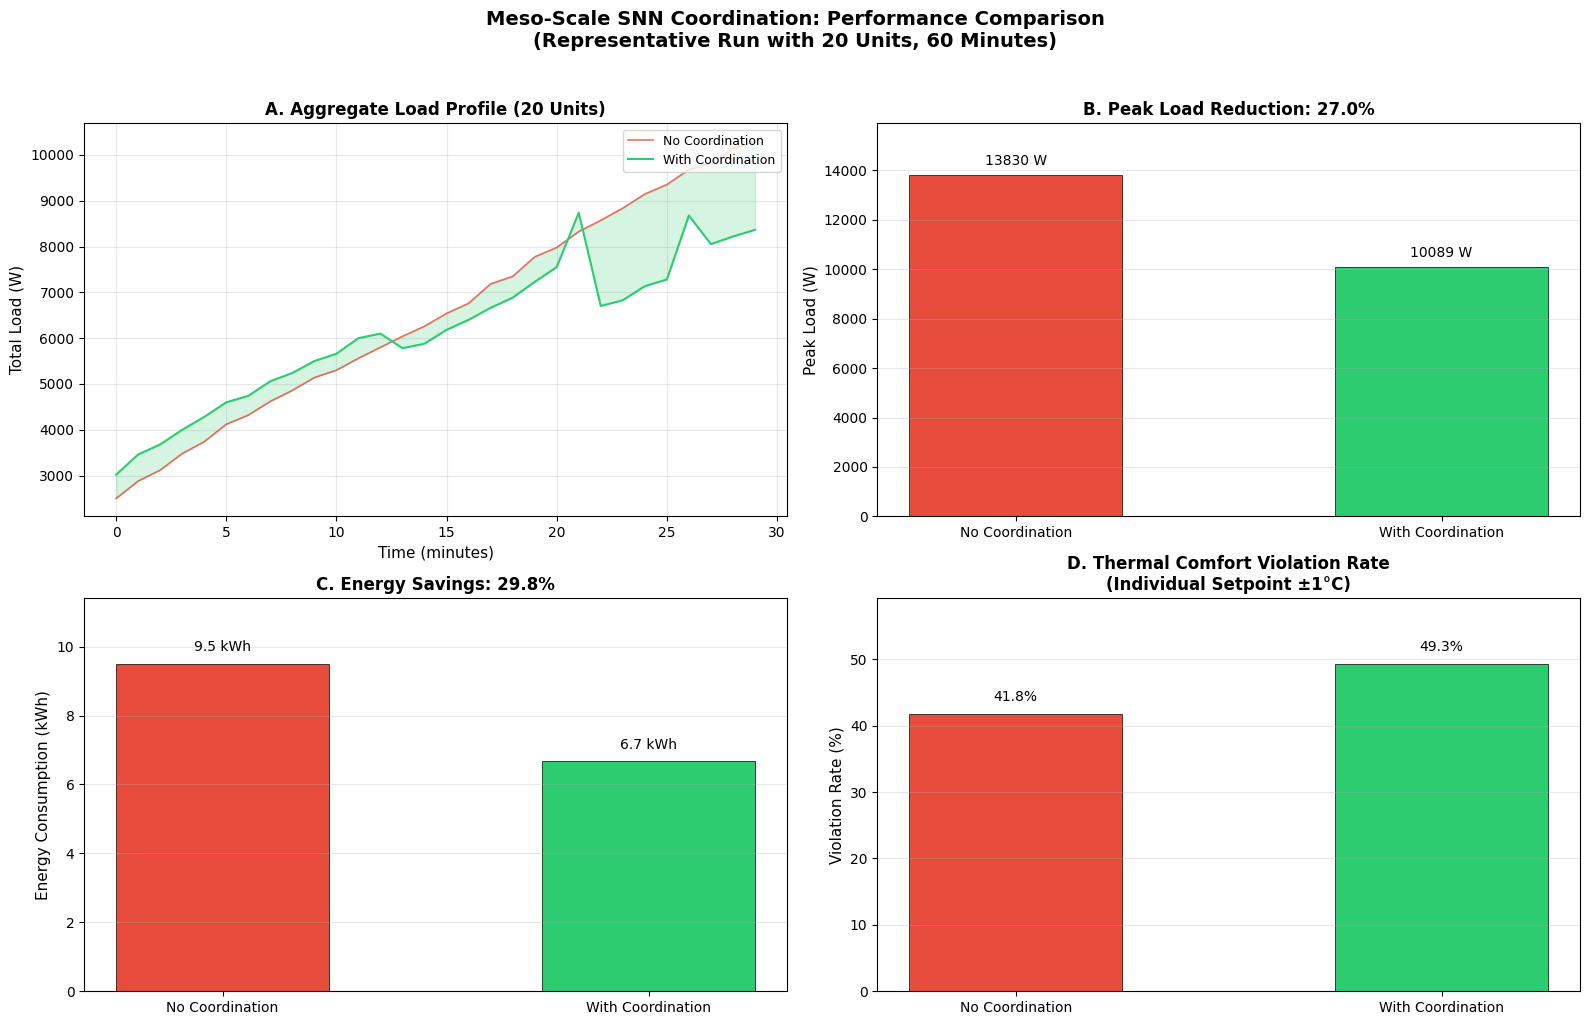


✅ Plot saved as 'meso_scale_representative_plot.png'

STATISTICAL SUMMARY (Mean ± Std from 30 runs)

📊 ENERGY (kWh):
   No Coordination:  9.5 ± 0.7
   With Coordination:6.6 ± 0.4
   Savings:          29.7 ± 7.1%

⚡ PEAK LOAD (W):
   No Coordination:  14045 ± 634
   With Coordination:10472 ± 794
   Reduction:        25.4 ± 5.7%

🌡️ VIOLATION RATE (Individual Setpoint, %):
   No Coordination:  43.4 ± 7.0
   With Coordination:44.2 ± 8.1
   Difference:       +0.8 ± 12.1%

⚡ COORDINATION ACTIVITY:
   Spikes:           3,373 ± 716
   Delays:           937 ± 345
   Broadcasts:       3,373 ± 716

FINAL TABLE FOR PAPER (Mean ± Std)

Metric                              No Coordination           With Coordination        
-------------------------------------------------------------------------------------
Energy (kWh)                        9.5                       6.6                      
Energy Savings (%)                  -                         29.7                     
Peak Load (W)    

In [19]:
print("\n" + "=" * 70)
print("MESO-SCALE MULTIPLE RUNS + REPRESENTATIVE PLOT GENERATION")
print("=" * 70)

# =========================================================
# PARAMETERS
# =========================================================
n_runs = 30  # Jumlah run (bisa dinaikkan untuk paper)
print(f"\n📊 Running {n_runs} simulations with different random seeds...")

# Storage for results
results_summary = {
    'energy_no': [], 'energy_with': [],
    'peak_no': [], 'peak_with': [],
    'viol_no': [], 'viol_with': [],
    'spikes': [], 'delays': [], 'broadcasts': []
}

# Storage for full time series data (hanya untuk run representatif)
representative_data = None
representative_idx = None

# Function to calculate violation individual
def calc_violation_individual(unit_temp_history, unit_setpoints_history, tolerance=1.0):
    violations = 0
    total = 0
    for temps, setpoints in zip(unit_temp_history, unit_setpoints_history):
        for temp, setpoint in zip(temps, setpoints):
            if abs(temp - setpoint) > tolerance:
                violations += 1
            total += 1
    return violations / total * 100 if total > 0 else 0

# =========================================================
# RUN MULTIPLE SIMULATIONS
# =========================================================
all_energies_with = []

for run in range(n_runs):
    print(f"\n--- Run {run+1}/{n_runs} ---")
    np.random.seed(run)

    # NO COORDINATION
    result_no = run_meso_simulation(
        n_units=20,
        duration_minutes=60,
        coordination_enabled=False,
        delay_threshold=3,
        delay_duration=4,
        delay_probability=0.5
    )

    # WITH COORDINATION
    result_with = run_meso_simulation(
        n_units=20,
        duration_minutes=60,
        coordination_enabled=True,
        delay_threshold=3,
        delay_duration=4,
        delay_probability=0.5,
        broadcast_threshold=0.2,
        broadcast_probability=0.4
    )

    # Calculate violation
    viol_no = calc_violation_individual(result_no['unit_temp_history'], result_no['unit_setpoints_history'])
    viol_with = calc_violation_individual(result_with['unit_temp_history'], result_with['unit_setpoints_history'])

    # Store results
    results_summary['energy_no'].append(result_no['energy'])
    results_summary['energy_with'].append(result_with['energy'])
    results_summary['peak_no'].append(result_no['peak'])
    results_summary['peak_with'].append(result_with['peak'])
    results_summary['viol_no'].append(viol_no)
    results_summary['viol_with'].append(viol_with)
    results_summary['spikes'].append(result_with['spikes'])
    results_summary['delays'].append(result_with['delays'])
    results_summary['broadcasts'].append(result_with['broadcasts'])

    all_energies_with.append(result_with['energy'])

    print(f"   Energy: No={result_no['energy']:.1f}, With={result_with['energy']:.1f} kWh")
    print(f"   Peak: No={result_no['peak']:.0f}, With={result_with['peak']:.0f} W")
    print(f"   Violation: No={viol_no:.1f}%, With={viol_with:.1f}%")

    # Store full data for first run (akan diganti dengan run terbaik)
    if run == 0:
        representative_data = {
            'load_no': result_no['load'],
            'load_with': result_with['load'],
            'temp_no': result_no['temp'],
            'temp_with': result_with['temp'],
            'energy_no': result_no['energy'],
            'energy_with': result_with['energy'],
            'peak_no': result_no['peak'],
            'peak_with': result_with['peak'],
            'spikes': result_with['spikes'],
            'delays': result_with['delays'],
            'broadcasts': result_with['broadcasts'],
            'unit_temp_history_no': result_no['unit_temp_history'],
            'unit_temp_history_with': result_with['unit_temp_history'],
            'unit_setpoints_history_no': result_no['unit_setpoints_history'],
            'unit_setpoints_history_with': result_with['unit_setpoints_history'],
        }

# =========================================================
# SELECT REPRESENTATIVE RUN (closest to mean energy)
# =========================================================
print("\n" + "=" * 70)
print("SELECTING REPRESENTATIVE RUN")
print("=" * 70)

energy_mean = np.mean(results_summary['energy_with'])
energy_std = np.std(results_summary['energy_with'])

distances = [abs(results_summary['energy_with'][i] - energy_mean) for i in range(n_runs)]
best_run_idx = np.argmin(distances)

print(f"\n📊 Representative run: Run {best_run_idx + 1}")
print(f"   Energy With Coordination: {results_summary['energy_with'][best_run_idx]:.1f} kWh")
print(f"   (Mean: {energy_mean:.1f} ± {energy_std:.1f} kWh)")
print(f"   Peak With: {results_summary['peak_with'][best_run_idx]:.0f} W")
print(f"   Violation With: {results_summary['viol_with'][best_run_idx]:.1f}%")

# =========================================================
# RE-RUN WITH BEST SEED TO GET FULL DATA
# =========================================================
print("\n" + "-" * 50)
print(f"Re-running with seed {best_run_idx} to get full data...")
print("-" * 50)

np.random.seed(best_run_idx)

# Run with best seed
result_no_best = run_meso_simulation(
    n_units=20,
    duration_minutes=60,
    coordination_enabled=False,
    delay_threshold=3,
    delay_duration=4,
    delay_probability=0.5
)

result_with_best = run_meso_simulation(
    n_units=20,
    duration_minutes=60,
    coordination_enabled=True,
    delay_threshold=3,
    delay_duration=4,
    delay_probability=0.5,
    broadcast_threshold=0.2,
    broadcast_probability=0.5
)

viol_no_best = calc_violation_individual(
    result_no_best['unit_temp_history'],
    result_no_best['unit_setpoints_history']
)
viol_with_best = calc_violation_individual(
    result_with_best['unit_temp_history'],
    result_with_best['unit_setpoints_history']
)

print(f"\n   Representative run results:")
print(f"   Energy: No={result_no_best['energy']:.1f}, With={result_with_best['energy']:.1f} kWh")
print(f"   Peak: No={result_no_best['peak']:.0f}, With={result_with_best['peak']:.0f} W")
print(f"   Violation: No={viol_no_best:.1f}%, With={viol_with_best:.1f}%")

# =========================================================
# GENERATE PLOT FOR REPRESENTATIVE RUN (FIXED)
# =========================================================
print("\n" + "=" * 70)
print("GENERATING PLOT FOR REPRESENTATIVE RUN")
print("=" * 70)

time_minutes = np.arange(len(result_no_best['load'])) * 60 / 60
plot_duration = 30
plot_steps = min(int(plot_duration * 60 / 60), len(time_minutes))
time_plot = time_minutes[:plot_steps]

# Create figure with more spacing
fig = plt.figure(figsize=(16, 10))
fig.subplots_adjust(hspace=0.35, wspace=0.3)

# Plot 1: Load Profile Comparison (top left)
ax1 = plt.subplot(2, 2, 1)
ax1.plot(time_plot, result_no_best['load'][:plot_steps],
         label='No Coordination', linewidth=1.2, color='#e74c3c', alpha=0.8)
ax1.plot(time_plot, result_with_best['load'][:plot_steps],
         label='With Coordination', linewidth=1.5, color='#2ecc71')
ax1.fill_between(time_plot, result_no_best['load'][:plot_steps],
                  result_with_best['load'][:plot_steps], alpha=0.2, color='#2ecc71')
ax1.set_ylabel('Total Load (W)', fontsize=11)
ax1.set_xlabel('Time (minutes)', fontsize=11)
ax1.set_title('A. Aggregate Load Profile (20 Units)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Peak Load Bar Chart (top right)
ax2 = plt.subplot(2, 2, 2)
peak_no = result_no_best['peak']
peak_with = result_with_best['peak']
peak_reduction = (peak_no - peak_with) / peak_no * 100

methods = ['No Coordination', 'With Coordination']
peak_values = [peak_no, peak_with]
colors = ['#e74c3c', '#2ecc71']
bars = ax2.bar(methods, peak_values, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
ax2.set_ylabel('Peak Load (W)', fontsize=11)
ax2.set_title(f'B. Peak Load Reduction: {peak_reduction:.1f}%', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
# Tambahkan margin atas untuk teks
ax2.set_ylim(0, max(peak_values) * 1.15)
for bar, val in zip(bars, peak_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(peak_values)*0.02,
             f'{val:.0f} W', ha='center', va='bottom', fontsize=10)

# Plot 3: Energy Consumption Bar Chart (bottom left)
ax3 = plt.subplot(2, 2, 3)
energy_no = result_no_best['energy']
energy_with = result_with_best['energy']
energy_savings = (energy_no - energy_with) / energy_no * 100

energy_values = [energy_no, energy_with]
bars = ax3.bar(methods, energy_values, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
ax3.set_ylabel('Energy Consumption (kWh)', fontsize=11)
ax3.set_title(f'C. Energy Savings: {energy_savings:.1f}%', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# Tambahkan margin atas untuk teks
ax3.set_ylim(0, max(energy_values) * 1.2)
for bar, val in zip(bars, energy_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(energy_values)*0.03,
             f'{val:.1f} kWh', ha='center', va='bottom', fontsize=10)

# Plot 4: Violation Rate Bar Chart (bottom right) - TANPA ANNOTATION
ax4 = plt.subplot(2, 2, 4)
viol_no = viol_no_best
viol_with = viol_with_best

viol_values = [viol_no, viol_with]
bars = ax4.bar(methods, viol_values, color=colors, edgecolor='black', linewidth=0.5, width=0.5)
ax4.set_ylabel('Violation Rate (%)', fontsize=11)
ax4.set_title('D. Thermal Comfort Violation Rate\n(Individual Setpoint ±1°C)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
# Tambahkan margin atas untuk teks
ax4.set_ylim(0, max(viol_values) * 1.2)
for bar, val in zip(bars, viol_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(viol_values)*0.03,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Meso-Scale SNN Coordination: Performance Comparison\n(Representative Run with 20 Units, 60 Minutes)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('meso_scale_representative_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved as 'meso_scale_representative_plot.png'")

# =========================================================
# STATISTICAL SUMMARY
# =========================================================
print("\n" + "=" * 70)
print("STATISTICAL SUMMARY (Mean ± Std from {} runs)".format(n_runs))
print("=" * 70)

savings = [(results_summary['energy_no'][i] - results_summary['energy_with'][i]) / results_summary['energy_no'][i] * 100 for i in range(n_runs)]
peak_reductions = [(results_summary['peak_no'][i] - results_summary['peak_with'][i]) / results_summary['peak_no'][i] * 100 for i in range(n_runs)]
viol_diff = [results_summary['viol_with'][i] - results_summary['viol_no'][i] for i in range(n_runs)]

print(f"\n📊 ENERGY (kWh):")
print(f"   No Coordination:  {np.mean(results_summary['energy_no']):.1f} ± {np.std(results_summary['energy_no']):.1f}")
print(f"   With Coordination:{np.mean(results_summary['energy_with']):.1f} ± {np.std(results_summary['energy_with']):.1f}")
print(f"   Savings:          {np.mean(savings):.1f} ± {np.std(savings):.1f}%")

print(f"\n⚡ PEAK LOAD (W):")
print(f"   No Coordination:  {np.mean(results_summary['peak_no']):.0f} ± {np.std(results_summary['peak_no']):.0f}")
print(f"   With Coordination:{np.mean(results_summary['peak_with']):.0f} ± {np.std(results_summary['peak_with']):.0f}")
print(f"   Reduction:        {np.mean(peak_reductions):.1f} ± {np.std(peak_reductions):.1f}%")

print(f"\n🌡️ VIOLATION RATE (Individual Setpoint, %):")
print(f"   No Coordination:  {np.mean(results_summary['viol_no']):.1f} ± {np.std(results_summary['viol_no']):.1f}")
print(f"   With Coordination:{np.mean(results_summary['viol_with']):.1f} ± {np.std(results_summary['viol_with']):.1f}")
print(f"   Difference:       {np.mean(viol_diff):+.1f} ± {np.std(viol_diff):.1f}%")

print(f"\n⚡ COORDINATION ACTIVITY:")
print(f"   Spikes:           {np.mean(results_summary['spikes']):,.0f} ± {np.std(results_summary['spikes']):,.0f}")
print(f"   Delays:           {np.mean(results_summary['delays']):,.0f} ± {np.std(results_summary['delays']):,.0f}")
print(f"   Broadcasts:       {np.mean(results_summary['broadcasts']):,.0f} ± {np.std(results_summary['broadcasts']):,.0f}")

# =========================================================
# FINAL TABLE FOR PAPER
# =========================================================
print("\n" + "=" * 70)
print("FINAL TABLE FOR PAPER (Mean ± Std)")
print("=" * 70)

print(f"\n{'Metric':<35} {'No Coordination':<25} {'With Coordination':<25}")
print("-" * 85)
print(f"{'Energy (kWh)':<35} {np.mean(results_summary['energy_no']):<25.1f} {np.mean(results_summary['energy_with']):<25.1f}")
print(f"{'Energy Savings (%)':<35} {'-':<25} {np.mean(savings):<25.1f}")
print(f"{'Peak Load (W)':<35} {np.mean(results_summary['peak_no']):<25.0f} {np.mean(results_summary['peak_with']):<25.0f}")
print(f"{'Peak Reduction (%)':<35} {'-':<25} {np.mean(peak_reductions):<25.1f}")
print(f"{'Violation Rate (Individual %)':<35} {np.mean(results_summary['viol_no']):<25.1f} {np.mean(results_summary['viol_with']):<25.1f}")
print(f"{'Total Spikes':<35} {'-':<25} {np.mean(results_summary['spikes']):<25,.0f}")
print(f"{'Total Delays':<35} {'-':<25} {np.mean(results_summary['delays']):<25,.0f}")

